# 02. 시계열 데이터의 이해와 실습

> **Day 01 — 제조 시계열 AI**
> - 제조 센서 시계열의 특성을 이해하고, 전처리와 시간 기반 분할까지 이후 모든 실습의 토대를 만든다.
> - 여기서 만든 함수(`make_windows`, 시간 기반 분할, train-only 스케일링)는 계속 재사용한다.

---

## 목차
1. 시계열은 왜 다른가 — 순서에 정보가 있는 데이터
2. 왜 중요한가 — 사후보전과 예지보전
3. 제조 센서 데이터 살펴보기
4. 시간 인덱싱과 리샘플링
5. 결측 처리 — 채울 것인가, 제외할 것인가
6. 자기상관(ACF) 확인하기
7. 슬라이딩 윈도우 데이터셋 생성
8. 시간 기반 분할과 스케일링 — 미래 정보가 새지 않게

In [29]:
# 공통 준비 — Colab / 로컬 양쪽에서 동작
import os, random, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"PyTorch {torch.__version__} | device: {DEVICE}")
except ImportError:
    DEVICE = "cpu"
    print("PyTorch 미설치 — 다음 셀에서 설치합니다.")

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False
print(f"Colab 환경: {IN_COLAB}")

PyTorch 2.11.0+cpu | device: cpu
Colab 환경: True


In [30]:
# 패키지 설치 (Colab 기본 탑재 외 추가분만)
!pip install -qU statsmodels

In [31]:
# ══ 실습 자료 위치 — 강사가 배포한 주소로 이 한 줄만 맞추면 됩니다 ══════════
DATA_REPO = "https://raw.githubusercontent.com/leejiyoon52/ai-course/main/day1"

# Google Drive로 배포받았다면, 위 줄 대신 아래 두 줄의 주석을 푸십시오.
# from google.colab import drive; drive.mount("/content/drive")
# DATA_REPO = "file:///content/drive/MyDrive/ai-course/day1"
# ═══════════════════════════════════════════════════════════════════════

import os, shutil, urllib.request
os.environ["MFG_DATA_BASE"] = DATA_REPO          # loaders.py가 이 값을 읽습니다

for f in ["mfg_datagen.py", "loaders.py"]:
    if os.path.exists(f):
        continue
    src = f"{DATA_REPO}/modules/{f}"
    try:
        if src.startswith("file://"):
            shutil.copy(src[len("file://"):], f)
        else:
            urllib.request.urlretrieve(src, f)
        print(f"다운로드 완료: {f}")
    except Exception:
        print(f"⚠️ {f} 를 받지 못했습니다 — 왼쪽 파일 탭에 직접 업로드해 주세요")

import mfg_datagen
import loaders
print(f"실습 모듈 준비 완료 — 자료 위치: {DATA_REPO}")

실습 모듈 준비 완료 — 자료 위치: https://raw.githubusercontent.com/leejiyoon52/ai-course/main/day1


---
## 1. 시계열은 왜 다른가 — 순서에 정보가 있는 데이터

일반 정형 데이터는 행의 순서를 바꿔도 정보가 보존됩니다. 시계열은 다릅니다.

- **순서**: 값의 의미가 "언제"에 묶여 있습니다.
- **자기상관**: 지금 값은 조금 전 값과 닮아 있습니다.
- **비정상성**: 평균·분산 자체가 시간에 따라 변합니다 (마모, 계절, 교대조).

실제로 행을 섞어서 어떤 정보가 사라지는지 확인해 보겠습니다.
데이터는 **CNC 스핀들**(공작기계의 회전축) 진동·부하 센서입니다.
CNC(Computer Numerical Control) 밀링머신이나 선반에서 공구를 고속으로 회전시키는 축으로,
베어링이 마모되거나 공구날이 무뎌지면 진동과 부하가 먼저 움직입니다.

**데이터 설명(Data Description)**

| 항목 | 내용 |
|---|---|
| 샘플링 | 10초 간격 |
| 규모 | 48시간 ≈ **17,280행** |
| 컬럼 | `vib_rms`(진동 RMS, mm/s) · `spindle_load`(스핀들 부하, %) · `tool_age_min`(공구 사용 시간, 분) |

세 컬럼 모두 합성 데이터입니다 — 결측 블록·홀드값·이상을 **의도적으로 심어야** 이후 절의 검진 실습이 성립하기 때문입니다.
`tool_age_min`은 공구를 교체할 때마다 0으로 리셋되고, `vib_rms`는 공구가 마모될수록 진폭이 서서히 커집니다.

In [32]:
# CNC 스핀들 데이터 생성 — 48시간, 10초 샘플링
cnc, cnc_labels = mfg_datagen.gen_cnc_spindle(n_hours=48, seed=SEED, return_labels=True)
print(f"shape: {cnc.shape} | 컬럼: {list(cnc.columns)}")
print(f"기간: {cnc.index[0]} ~ {cnc.index[-1]}")
cnc.head()

shape: (17280, 3) | 컬럼: ['vib_rms', 'spindle_load', 'tool_age_min']
기간: 2025-03-03 08:00:00 ~ 2025-03-05 07:59:50


,vib_rms,spindle_load,tool_age_min
2025-03-03 08:00:00,0.918283,75.723843,0.000000
2025-03-03 08:00:10,1.140715,67.641791,0.166667
2025-03-03 08:00:20,1.248151,66.477498,0.333333
2025-03-03 08:00:30,0.956461,74.220977,0.500000
2025-03-03 08:00:40,1.086088,73.303470,0.666667


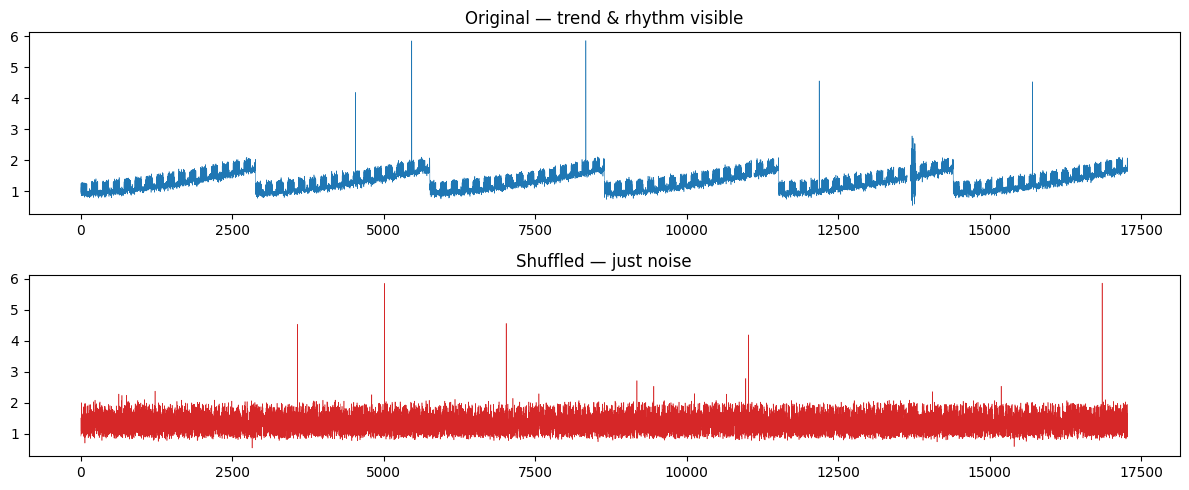

같은 값들인데도 마모 추세와 가공 리듬은 모두 사라졌습니다.


In [33]:
# 행을 무작위로 섞으면 무엇이 사라지는지 비교한다
import matplotlib.pyplot as plt

shuffled = cnc["vib_rms"].sample(frac=1.0, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharey=True)
axes[0].plot(cnc["vib_rms"].values, lw=0.4)
axes[0].set_title("Original — trend & rhythm visible")
axes[1].plot(shuffled.values, lw=0.4, color="tab:red")
axes[1].set_title("Shuffled — just noise")
plt.tight_layout()
plt.show()
print("같은 값들인데도 마모 추세와 가공 리듬은 모두 사라졌습니다.")

In [34]:
# 자기상관을 숫자로 확인 — "지금 값은 조금 전 값과 비슷하다"
for lag in [1, 6, 60]:
    r = cnc["vib_rms"].autocorr(lag=lag)
    print(f"lag {lag:3d} ({lag * 10:4d}초 전)과의 상관: {r:+.3f}")
print("섞은 뒤에는:", round(shuffled.autocorr(lag=1), 3), "— 바로 앞 시점과 닮았던 성질이 사라졌습니다")

'''
① 세 lag 모두 강한 양의 상관 (+0.63~+0.87)
지금 값이 몇 초~몇백 초 전 값과 상당히 닮아 있다는 뜻입니다. 즉 이 신호는 "시점을 뒤섞어도 정보가 그대로"인 데이터가 아니라, 순서 자체에 정보가 있는 데이터입니다 
슬라이딩 윈도우로 과거 구간을 묶어 입력으로 쓰는 이유가 바로 이겁니다.

② lag 6(60초 전)이 lag 1(10초 전)보다 오히려 높습니다 (0.865 > 0.682)
이게 흥미로운 지점입니다. 순수 잡음이라면 상관은 lag가 커질수록 단조롭게(monotonic) 줄어들어야 하는데, 여기선 중간에 봉우리가 생겼습니다. 
이는 신호에 주기적 성분이 섞여 있다는 신호입니다 — 예를 들어 스핀들 회전·가공 사이클이 대략 60초 근방의 주기를 가진다면, 
"같은 사이클 위상"에 있는 60초 전 값이 바로 직전 값보다 더 닮아 보일 수 있습니다. (10초 간격 샘플링이니 lag=6이 정확히 60초입니다.)

③ lag 60(600초 전)도 여전히 +0.632로 꽤 높습니다
단순히 "최근 몇 초"만 닮은 게 아니라, 훨씬 먼 과거와도 구조적으로 연결돼 있다는 뜻 — 위 ②의 주기성 또는 느린 열화·드리프트 추세가 겹쳐 있을 가능성을 보여줍니다.

④ 섞은 뒤 상관이 0.006으로 사라짐 — 이게 통제 실험 역할
이 대조군이 핵심입니다. 원본의 높은 상관이 우연이나 계산상 착시가 아니라, 진짜로 시간 순서 때문에 생긴 것임을 증명합니다. 
값의 분포는 그대로 두고 순서만 깨뜨렸는데 상관이 통째로 없어졌으니, "순서가 정보를 담고 있다"는 이 노트북의 핵심 주장이 숫자로 확인된 겁니다.
'''

lag   1 (  10초 전)과의 상관: +0.682
lag   6 (  60초 전)과의 상관: +0.865
lag  60 ( 600초 전)과의 상관: +0.632
섞은 뒤에는: 0.006 — 바로 앞 시점과 닮았던 성질이 사라졌습니다


'\n① 세 lag 모두 강한 양의 상관 (+0.63~+0.87)\n지금 값이 몇 초~몇백 초 전 값과 상당히 닮아 있다는 뜻입니다. 즉 이 신호는 "시점을 뒤섞어도 정보가 그대로"인 데이터가 아니라, 순서 자체에 정보가 있는 데이터입니다 \n슬라이딩 윈도우로 과거 구간을 묶어 입력으로 쓰는 이유가 바로 이겁니다.\n\n② lag 6(60초 전)이 lag 1(10초 전)보다 오히려 높습니다 (0.865 > 0.682)\n이게 흥미로운 지점입니다. 순수 잡음이라면 상관은 lag가 커질수록 단조롭게(monotonic) 줄어들어야 하는데, 여기선 중간에 봉우리가 생겼습니다. \n이는 신호에 주기적 성분이 섞여 있다는 신호입니다 — 예를 들어 스핀들 회전·가공 사이클이 대략 60초 근방의 주기를 가진다면, \n"같은 사이클 위상"에 있는 60초 전 값이 바로 직전 값보다 더 닮아 보일 수 있습니다. (10초 간격 샘플링이니 lag=6이 정확히 60초입니다.)\n\n③ lag 60(600초 전)도 여전히 +0.632로 꽤 높습니다\n단순히 "최근 몇 초"만 닮은 게 아니라, 훨씬 먼 과거와도 구조적으로 연결돼 있다는 뜻 — 위 ②의 주기성 또는 느린 열화·드리프트 추세가 겹쳐 있을 가능성을 보여줍니다.\n\n④ 섞은 뒤 상관이 0.006으로 사라짐 — 이게 통제 실험 역할\n이 대조군이 핵심입니다. 원본의 높은 상관이 우연이나 계산상 착시가 아니라, 진짜로 시간 순서 때문에 생긴 것임을 증명합니다. \n값의 분포는 그대로 두고 순서만 깨뜨렸는데 상관이 통째로 없어졌으니, "순서가 정보를 담고 있다"는 이 노트북의 핵심 주장이 숫자로 확인된 겁니다.\n'

---
## 2. 왜 중요한가 — 사후보전과 예지보전

> 시계열 파형을 보면 설비 상태를 알 수 있고, **고장이 나기 전에 신호가 먼저 흔들립니다.**

**사후보전(Run-to-Failure)**은 설비가 멈춘 뒤에야 대응하는 방식이고,
**예지보전(PdM, Predictive Maintenance)**은 신호가 이상해지는 시점을 미리 잡아 대응하는 방식입니다.

| | 사후보전 (Run-to-Failure) | 예지보전 (PdM) |
|---|---|---|
| 대응 시점 | 멈춘 뒤 | 신호가 이상해진 시점 |
| 비용 | 비계획 정지 + 연쇄 지연 + 긴급 수리 | 계획 정비 (생산 계획에 흡수) |
| 필요한 것 | 없음 | 신호를 읽는 능력 |

방금 만든 CNC 데이터에서는 `vib_rms`(진동)가 공구 마모에 따라 서서히 커집니다.
이 변화를 공구가 완전히 마모되기 전에 잡아내는 것이 예지보전이고, 오늘 이 노트북에서 배울 내용입니다.
아래 그래프에서 공구 마모가 진동 신호에 어떻게 미리 나타나는지 확인합니다.

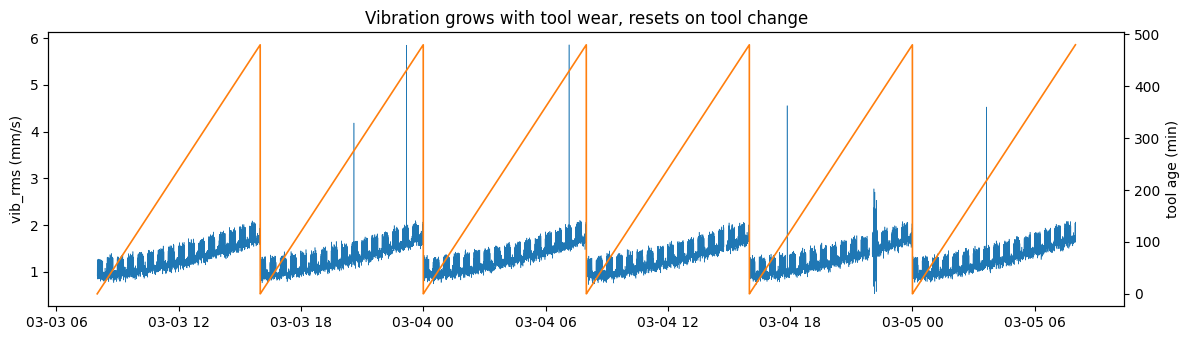

공구 교체(주황 톱니의 리셋) 직전마다 진동 진폭이 커져 있습니다 — 이 패턴이 예지보전의 근거입니다.


In [35]:
# 공구 마모(tool_age)와 진동(vib_rms)의 동행 — 고장은 신호에 먼저 나타난다. 공구 누적 사용시간은 약 8시간
fig, ax1 = plt.subplots(figsize=(12, 3.5))
ax1.plot(cnc.index, cnc["vib_rms"], lw=0.4, label="vib_rms")
ax1.set_ylabel("vib_rms (mm/s)")
ax2 = ax1.twinx()
ax2.plot(cnc.index, cnc["tool_age_min"], color="tab:orange", lw=1.2, label="tool_age")
ax2.set_ylabel("tool age (min)")
ax1.set_title("Vibration grows with tool wear, resets on tool change")
plt.tight_layout()
plt.show()
print("공구 교체(주황 톱니의 리셋) 직전마다 진동 진폭이 커져 있습니다 — 이 패턴이 예지보전의 근거입니다.")

In [36]:
# 비계획 정지 1회와 계획 정비 1회의 비용 차이
HOURLY_LOSS = 300        # 라인 정지 시간당 기회손실 (만원, 예시)
unplanned = 6 * HOURLY_LOSS + 500 + 300   # 돌발 정지 6시간 + 긴급수리 + 불량 재작업
planned = 2 * HOURLY_LOSS + 200           # 계획 정비 2시간(야간 배치) + 정기 부품비

print(f"비계획 정지 1회: 약 {unplanned:,}만원")
print(f"계획 정비 1회  : 약 {planned:,}만원")
print(f"차이           : {unplanned - planned:,}만원 → 신호를 읽는 능력의 값어치입니다")
print("(숫자는 예시입니다 — 실제로는 공정·업종별 비용 구조로 다시 계산해야 합니다)")

비계획 정지 1회: 약 2,600만원
계획 정비 1회  : 약 800만원
차이           : 1,800만원 → 신호를 읽는 능력의 값어치입니다
(숫자는 예시입니다 — 실제로는 공정·업종별 비용 구조로 다시 계산해야 합니다)


---
## 3. 제조 센서 데이터 살펴보기

생산라인 전력 데이터에는 하루 단위(교대조)와 주 단위(요일)로 반복되는 패턴,
그리고 설비 노후화에 따른 장기 추세가 함께 섞여 있습니다. 이 패턴들을 그래프로 확인합니다.

**데이터 설명(Data Description)**

| 항목 | 내용 |
|---|---|
| 샘플링 | 10분 간격 |
| 규모 | 28일 ≈ **4,032행** |
| 컬럼 | `power_kw`(라인 전력 사용량, kW) |

주간조(08~20시)는 부하가 높고 야간조는 낮게, 주말은 감산 운전으로 더 낮게 설계된 합성 데이터입니다.
설비 노후화에 따른 완만한 상승 추세와, 계획 정지(PM, Preventive Maintenance — 예방 정비) 구간도 하나 섞여 있습니다.

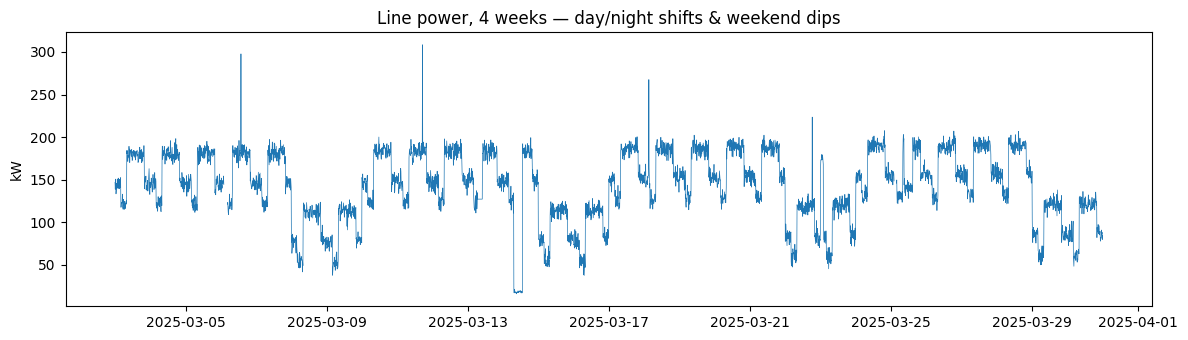

shape: (4032, 1)


In [37]:
# 생산라인 전력 데이터 생성 — 4주, 10분 샘플링
energy = mfg_datagen.gen_line_energy(n_days=28, seed=SEED)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(energy.index, energy["power_kw"], lw=0.5)
ax.set_title("Line power, 4 weeks — day/night shifts & weekend dips")
ax.set_ylabel("kW")
plt.tight_layout()
plt.show()
print(f"shape: {energy.shape}")

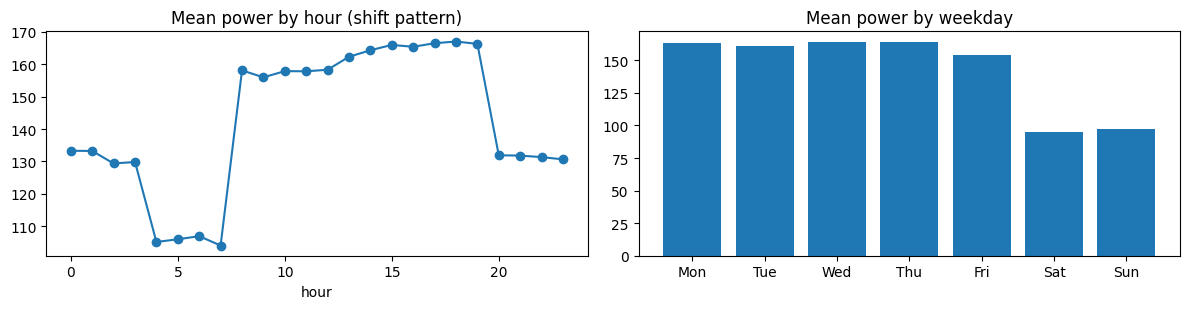

08~20시 주간조 부하, 주말 감산 — 이 패턴을 모르면 주말 새벽 가동이 '정상'으로 보입니다.


In [38]:
# 시간대·요일 프로파일 — 교대조와 요일 효과를 평균으로 요약
prof_h = energy.groupby(energy.index.hour)["power_kw"].mean()
prof_d = energy.groupby(energy.index.dayofweek)["power_kw"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].plot(prof_h.index, prof_h.values, marker="o")
axes[0].set_title("Mean power by hour (shift pattern)")
axes[0].set_xlabel("hour")
axes[1].bar(range(7), prof_d.values)
axes[1].set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_title("Mean power by weekday")
plt.tight_layout()
plt.show()
print("08~20시 주간조 부하, 주말 감산 — 이 패턴을 모르면 주말 새벽 가동이 '정상'으로 보입니다.")

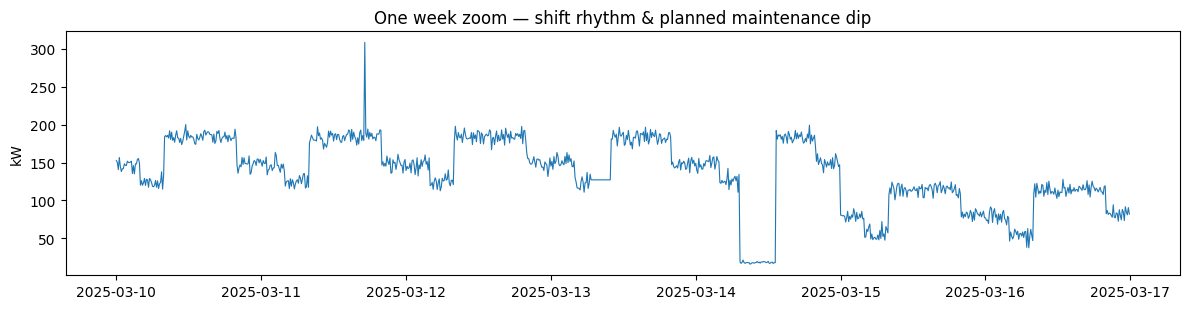

깊고 반듯한 저전력 구간은 계획 정지(PM)입니다.
값만 보면 이상 구간과 똑같이 튀어 보이지만, 일정에 따라 미리 잡아둔 정지라 고장이 아닙니다.
→ 이런 '정상이지만 특수한' 구간을 모델에 알려주지 않으면,
  PM마다 알람이 울리고, 알람 피로가 쌓여 진짜 이상이 떴을 때도 무시하게 됩니다.


In [39]:
# 1주만 확대 — 계획 정지(PM, Preventive Maintenance)와 이상 구간은 모양이 다르다
week = energy.loc["2025-03-10":"2025-03-16"]
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(week.index, week["power_kw"], lw=0.8)
ax.set_title("One week zoom — shift rhythm & planned maintenance dip")
ax.set_ylabel("kW")
plt.tight_layout()
plt.show()
print("깊고 반듯한 저전력 구간은 계획 정지(PM)입니다.")
print("값만 보면 이상 구간과 똑같이 튀어 보이지만, 일정에 따라 미리 잡아둔 정지라 고장이 아닙니다.")
print("→ 이런 '정상이지만 특수한' 구간을 모델에 알려주지 않으면,")
print("  PM마다 알람이 울리고, 알람 피로가 쌓여 진짜 이상이 떴을 때도 무시하게 됩니다.")

---
## 4. 시간 인덱싱과 리샘플링

> 샘플링 주기가 너무 성기면 짧은 이상 신호를 그대로 놓칩니다.

`DatetimeIndex` 가 있으면 시간이 곧 조회 키가 됩니다.
그리고 같은 데이터를 더 성긴 주기로 요약하려면 **리샘플링**이 필요합니다.
이때 컬럼마다 다른 집계 함수(mean / max / last)를 고르는 것이 곧
**어떤 정보를 남길 것인가**의 선택입니다.
(센서마다 원본 수집 주기 자체가 다를 때도 같은 방법으로 공통 시간축에 맞춥니다.)

In [40]:
# 문자열 타임스탬프를 DatetimeIndex로 변환 — 수집 로그를 시계열로 다룰 수 있게 만든다
import pandas as pd

raw = pd.DataFrame({
    "ts": ["2025-03-03 08:00:00", "2025-03-03 08:00:10", "2025-03-03 08:00:20"],
    "vib": [0.91, 0.88, 0.95],
})
raw["ts"] = pd.to_datetime(raw["ts"])
raw = raw.set_index("ts").sort_index()
print(raw)
print("\nindex 타입:", type(raw.index).__name__, "— 이제 시간이 조회 키가 됩니다")

                      vib
ts                       
2025-03-03 08:00:00  0.91
2025-03-03 08:00:10  0.88
2025-03-03 08:00:20  0.95

index 타입: DatetimeIndex — 이제 시간이 조회 키가 됩니다


In [41]:
# 특정 날짜/시간 기준으로 Slicing 하기
day1 = cnc.loc["2025-03-03"]
morning = cnc.between_time("09:00", "11:00")
print(f"3월 3일 하루      : {day1.shape[0]:,}행")
print(f"매일 09~11시 구간 : {morning.shape[0]:,}행")
print(day1.head(3).to_string())

3월 3일 하루      : 5,760행
매일 09~11시 구간 : 1,442행
                      vib_rms  spindle_load  tool_age_min
2025-03-03 08:00:00  0.918283     75.723843      0.000000
2025-03-03 08:00:10  1.140715     67.641791      0.166667
2025-03-03 08:00:20  1.248151     66.477498      0.333333


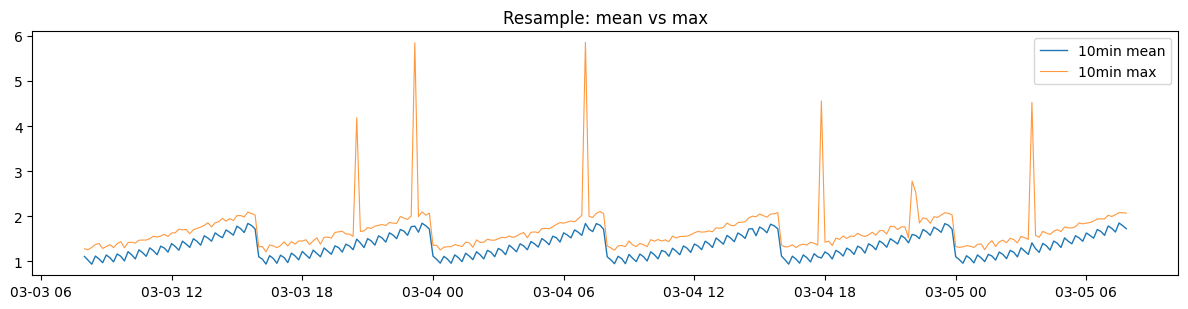

순간 스파이크(충돌 징후)는 mean에서는 사라지고 max에만 남습니다.


In [42]:
# 리샘플링 — 10초 → 10분. mean과 max는 남기는 정보가 다르다
"""채워넣기"""
# [채워넣기 안내] 학생용에서 다음 부분이 빈칸이 됩니다:
#   - .resample("10min").mean()
#   - .resample("10min").max()
vib_mean = cnc["vib_rms"].resample("10min").mean()
vib_max = cnc["vib_rms"].resample("10min").max()

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(vib_mean.index, vib_mean.values, label="10min mean", lw=1)
ax.plot(vib_max.index, vib_max.values, label="10min max", lw=0.8, alpha=0.8)
ax.set_title("Resample: mean vs max")
ax.legend()
plt.tight_layout()
plt.show()
print("순간 스파이크(충돌 징후)는 mean에서는 사라지고 max에만 남습니다.")

In [43]:
# 10분 단위로 리샘플링 — 컬럼마다 집계 함수를 다르게 선택한다
aligned = cnc.resample("10min").agg({
    "vib_rms": "max",        # 이상 징후 보존이 목적 → max
    "spindle_load": "mean",  # 평균 부하 수준이 목적 → mean
    "tool_age_min": "last",  # 상태값(누적) → 구간 마지막 값
})
print(aligned.head().round(3).to_string())
print(f"\n10초 데이터 {len(cnc):,}행 → 10분 요약 데이터 {len(aligned):,}행")

                     vib_rms  spindle_load  tool_age_min
2025-03-03 08:00:00    1.277        70.300         9.833
2025-03-03 08:10:00    1.257        54.042        19.833
2025-03-03 08:20:00    1.310        31.032        29.833
2025-03-03 08:30:00    1.372        70.209        39.833
2025-03-03 08:40:00    1.398        54.987        49.833

10초 데이터 17,280행 → 10분 요약 데이터 288행


---
## 5. 결측 처리 — 채울 것인가, 제외할 것인가

제조 데이터의 결측은 한 점씩 흩어지지 않습니다. 통신 두절·수집기 재시작 때문에
**연속 블록**으로 옵니다. 블록형 결측 앞에서 보간(interpolation)은 위험해집니다.

In [44]:
# 결측 블록의 위치와 길이를 찾는다 — run-length 계산
"""채워넣기"""
# [채워넣기 안내] 학생용에서 다음 부분이 빈칸이 됩니다:
#   - grp = (isna != isna.shift()).cumsum()
def find_na_blocks(s):
    """연속 NaN 블록의 (시작, 길이) 목록을 반환한다."""
    isna = s.isna()
    blocks = []
    grp = (isna != isna.shift()).cumsum()
    for _, g in s[isna].groupby(grp[isna]):
        blocks.append((g.index[0], len(g)))
    return blocks

blocks = find_na_blocks(cnc["vib_rms"])
for start, length in blocks:
    print(f"결측 블록: {start} 부터 {length}개 ({length * 10}초)")
print(f"총 결측: {cnc['vib_rms'].isna().sum()}개 — 전부 몇 개의 긴 블록에 몰려 있습니다")

결측 블록: 2025-03-04 14:45:10 부터 39개 (390초)
결측 블록: 2025-03-04 21:53:00 부터 51개 (510초)
총 결측: 90개 — 전부 몇 개의 긴 블록에 몰려 있습니다


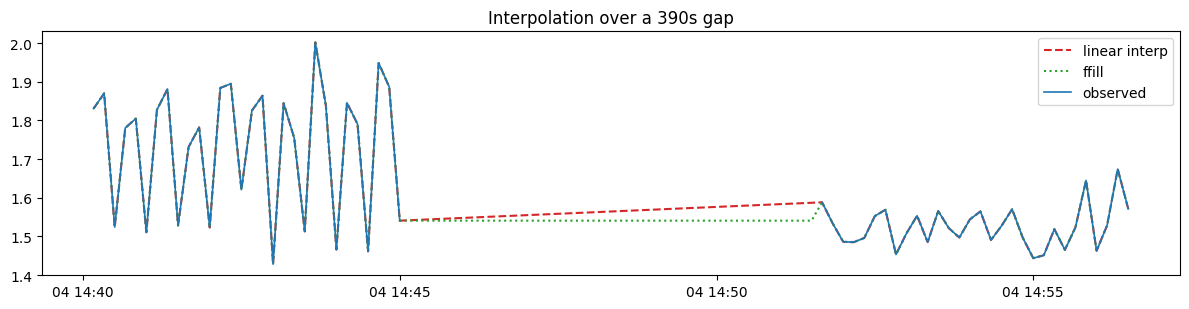

보간선은 진동의 패턴을 재현하지 못합니다 — 없는 데이터를 있는 것처럼 보이게 만들 뿐입니다.


In [45]:
# 보간 방법 비교 — 긴 블록에서 보간값은 실제로 없는 데이터입니다
"""채워넣기"""
# [채워넣기 안내] 학생용에서 다음 부분이 빈칸이 됩니다:
#   - seg.interpolate("linear")
start, length = blocks[0]
lo = cnc.index.get_loc(start) - 30
seg = cnc["vib_rms"].iloc[lo:lo + length + 60]

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(seg.index, seg.interpolate("linear").values, "--", label="linear interp", color="tab:red")
ax.plot(seg.index, seg.ffill().values, ":", label="ffill", color="tab:green")
ax.plot(seg.index, seg.values, lw=1.2, label="observed", color="tab:blue")
ax.set_title(f"Interpolation over a {length * 10}s gap")
ax.legend()
plt.tight_layout()
plt.show()
print("보간선은 진동의 패턴을 재현하지 못합니다 — 없는 데이터를 있는 것처럼 보이게 만들 뿐입니다.")

**판단 기준 — 채우지 말고 제외하는 선택**

- 짧은 결측(수 샘플): 보간해도 왜곡이 작습니다.
- **긴 블록**: 보간값은 학습 데이터를 오염시킵니다. **구간째 제외**가 안전합니다.
- 특히 이상탐지에서는 보간 구간이 "지나치게 매끈한 정상"으로 학습되어 탐지력을 깎아 먹습니다.

> **현장 노트**
> - "불량 라벨"은 검사 시점 기준입니다. 실제 이상 발생 시점과는 시차가 있습니다.
> - 검사가 2시간마다 돈다면, 라벨이 붙은 시점의 신호가 아니라 그 앞 구간 어딘가에 원인이 있습니다. 라벨을 믿고 시점을 그대로 쓰면 모델은 엉뚱한 구간을 학습합니다.
> - 라벨 시차 보정은 모델링보다 성능 개선에 기여할 수 있는 경우들도 많습니다.

In [46]:
# 구간 제외 — 결측 블록 주변까지 유효 마스크로 걸러낸다
valid = cnc["vib_rms"].notna()
for start, length in blocks:
    loc = cnc.index.get_loc(start)
    valid.iloc[max(0, loc - 3): loc + length + 3] = False   # 블록 앞뒤 3샘플 여유

print(f"전체 {len(cnc):,}행 중 유효 {valid.sum():,}행 사용 ({100 * valid.mean():.1f}%)")
print("이 마스크는 7절 슬라이딩 윈도우에서 '결측 걸친 윈도우 버리기'로 다시 씁니다.")

전체 17,280행 중 유효 17,178행 사용 (99.4%)
이 마스크는 7절 슬라이딩 윈도우에서 '결측 걸친 윈도우 버리기'로 다시 씁니다.


---
## 6. 자기상관(ACF) 확인하기

자기상관함수(ACF, Autocorrelation Function)는 "지금 값이 lag 시점 전 값과
얼마나 비슷한가"를 재는 도구입니다. **주기가 있으면 그 지점에서 상관관계가 다시 높아집니다.**

여기서는 사이클 주기를 확인하는 용도로만 사용합니다. (시계열 분해·정상성 검정은 이 과정 범위 밖입니다)

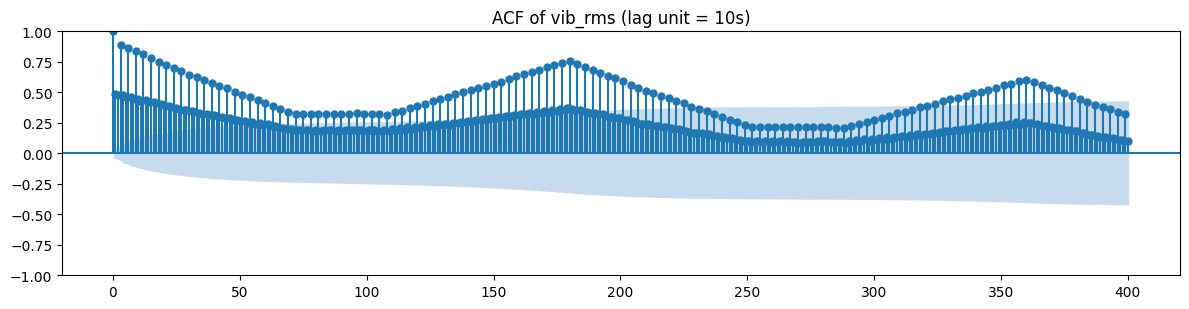

lag 180(=30분) 부근에서 상관이 다시 높아집니다 — 가공 사이클의 주기입니다.
이 주기가 7절에서 윈도우 길이를 정하는 근거가 됩니다.


In [47]:
# ACF로 가공 사이클 주기 확인 — 상관관계가 다시 높아지는 lag를 찾는다
"""채워넣기"""
# [채워넣기 안내] 학생용에서 다음 부분이 빈칸이 됩니다:
#   - plot_acf(series, lags=400, ax=ax)
from statsmodels.graphics.tsaplots import plot_acf

series = cnc["vib_rms"].dropna().iloc[:2000]
fig, ax = plt.subplots(figsize=(12, 3.2))
plot_acf(series, lags=400, ax=ax)
ax.set_title("ACF of vib_rms (lag unit = 10s)")
plt.tight_layout(); plt.show()
print("lag 180(=30분) 부근에서 상관이 다시 높아집니다 — 가공 사이클의 주기입니다.")
print("이 주기가 7절에서 윈도우 길이를 정하는 근거가 됩니다.")

---
## 7. 슬라이딩 윈도우 데이터셋 생성

> 슬라이딩 윈도우는 *긴 영상을 일정 길이 클립으로 잘라 보는 것*입니다.

모델은 무한히 긴 시계열을 한 번에 처리하지 못합니다.
`input_len` 길이의 과거를 보고 `horizon` 만큼의 미래를 맞히는 (X, y) 쌍으로 썰어야 합니다.
**이 함수는 NB03의 Patch 개념으로 그대로 이어집니다** — Patch는 윈도우 안을 또 한 번 써는 것입니다.

In [48]:
# 슬라이딩 윈도우 데이터셋 생성 — 오늘 하루 내내 재사용할 함수
"""채워넣기"""
# [채워넣기 안내] 학생용에서 다음 부분이 빈칸이 됩니다:
#   - series[i : i + input_len]
#   - series[i + input_len : i + input_len + horizon]
def make_windows(series, input_len=48, horizon=6):
    X, y = [], []
    for i in range(len(series) - input_len - horizon + 1):
        X.append(series[i : i + input_len])
        y.append(series[i + input_len : i + input_len + horizon])
    return np.array(X), np.array(y)

temp = cnc["vib_rms"].ffill().values          # 데모용으로 짧은 결측만 채움
X, y = make_windows(temp, input_len=48, horizon=6)
print(f"X: {X.shape} | y: {y.shape}")
print(f"→ 과거 {X.shape[1]}스텝(8분)을 보고 미래 {y.shape[1]}스텝(1분)을 예측하는 문제가 되었습니다")

X: (17227, 48) | y: (17227, 6)
→ 과거 48스텝(8분)을 보고 미래 6스텝(1분)을 예측하는 문제가 되었습니다


In [49]:
# 결측에 걸친 윈도우를 버린다
"""채워넣기"""
# [채워넣기 안내] 학생용에서 다음 부분이 빈칸이 됩니다:
#   - v[i : i + input_len + horizon].all()
def make_windows_masked(series, valid_mask, input_len=48, horizon=6):
    """
    series     : 윈도우로 썰 원본 시계열 값 (예: cnc["vib_rms"].ffill().values)
    valid_mask : series와 길이가 같은 불리언 Series — False인 지점은 결측·오염 구간
    input_len  : 하나의 윈도우가 보는 '과거' 길이 (X, 여기선 48스텝 = 8분)
    horizon    : 그 뒤에 맞혀야 할 '미래' 길이 (y, 여기선 6스텝 = 1분)
    """
    X, y, kept = [], [], 0
    v = valid_mask.values
    for i in range(len(series) - input_len - horizon + 1):
        if v[i : i + input_len + horizon].all():          # 창 전체가 유효할 때만 채택
            X.append(series[i : i + input_len])
            y.append(series[i + input_len : i + input_len + horizon])
            kept += 1
    return np.array(X), np.array(y)

Xm, ym = make_windows_masked(cnc["vib_rms"].ffill().values, valid)
n_bad = int((~valid).sum())
print(f"결측 + 여유 버퍼로 무효 표시된 지점: {n_bad}개")
print(f"마스크 적용 전 {len(X):,}개 → 적용 후 {len(Xm):,}개 윈도우 ({len(X) - len(Xm)}개 폐기)")
print("무효 지점 하나가 그 지점을 걸치는 윈도우를 전부 오염시키므로,")
print("폐기된 윈도우 수가 무효 지점 수보다 훨씬 많습니다 — 윈도우가 1칸씩 촘촘히 겹치기 때문입니다.")
print("오염된 창을 버리는 비용은 작고, 오염된 창을 학습하는 비용은 큽니다.")

결측 + 여유 버퍼로 무효 표시된 지점: 102개
마스크 적용 전 17,227개 → 적용 후 17,019개 윈도우 (208개 폐기)
무효 지점 하나가 그 지점을 걸치는 윈도우를 전부 오염시키므로,
폐기된 윈도우 수가 무효 지점 수보다 훨씬 많습니다 — 윈도우가 1칸씩 촘촘히 겹치기 때문입니다.
오염된 창을 버리는 비용은 작고, 오염된 창을 학습하는 비용은 큽니다.


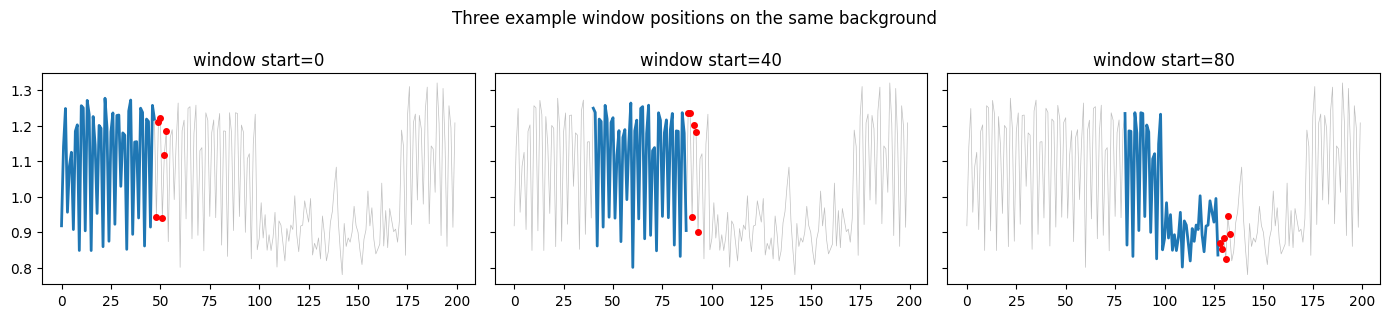

여기 s0=[0, 40, 80]은 보여주기 위해 고른 예시 간격일 뿐입니다.
실제 make_windows()는 range(...)의 기본 step=1이라 stride 파라미터가 없고,
가능한 모든 시작 위치(1칸씩)에서 윈도우를 만듭니다 — 예시보다 훨씬 촘촘하게 겹칩니다.


In [50]:
# 윈도우가 실제로 어떻게 겹치며 미끄러지는지 — 세 개의 예시 위치로 확인
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2), sharex=True, sharey=True)
for ax, s0 in zip(axes, [0, 40, 80]):
    ax.plot(temp[:200], lw=0.5, color="gray", alpha=0.5)               # 전체 배경(공통)
    ax.plot(range(s0, s0 + 48), temp[s0:s0 + 48], lw=2, color="tab:blue")
    ax.plot(range(s0 + 48, s0 + 54), temp[s0 + 48:s0 + 54], "r.", ms=8)
    ax.set_title(f"window start={s0}")
plt.suptitle("Three example window positions on the same background")
plt.tight_layout()
plt.show()
print("여기 s0=[0, 40, 80]은 보여주기 위해 고른 예시 간격일 뿐입니다.")
print("실제 make_windows()는 range(...)의 기본 step=1이라 stride 파라미터가 없고,")
print("가능한 모든 시작 위치(1칸씩)에서 윈도우를 만듭니다 — 예시보다 훨씬 촘촘하게 겹칩니다.")

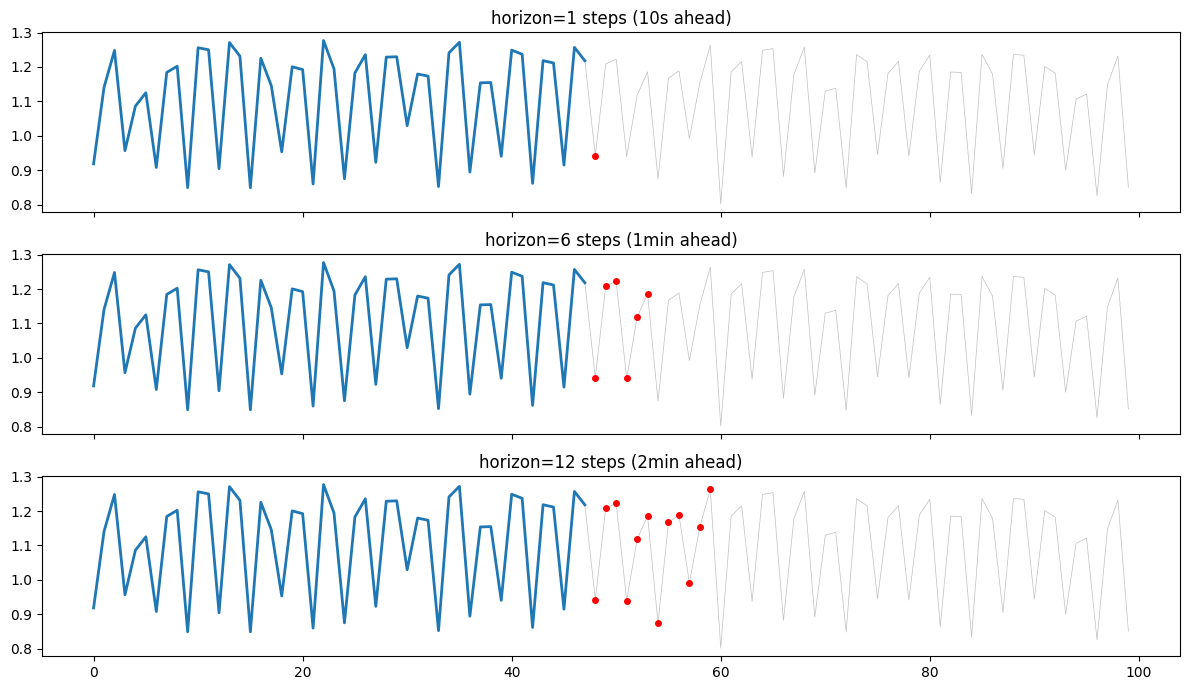

input_len(과거를 얼마나 볼지)은 그대로 두고, horizon(몇 스텝 앞을 맞힐지)만 바꿨습니다.
horizon 1스텝=10초, 6스텝=1분, 12스텝=2분입니다.
horizon이 길어질수록 맞히기는 어려워지지만, 현장에서 쓸모 있는 경고 시간은 길어집니다 — 트레이드오프입니다.


In [51]:
# 문제 설계는 하나가 아니다 — horizon(몇 스텝 앞을 맞힐지)을 바꿔가며 비교
HORIZONS = [(1, "10s ahead"), (6, "1min ahead"), (12, "2min ahead")]
s0 = 0

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(12, 7), sharex=True)
for ax, (h, name) in zip(axes, HORIZONS):
    ax.plot(temp[:100], lw=0.5, color="gray", alpha=0.5)
    ax.plot(range(s0, s0 + 48), temp[s0:s0 + 48], lw=2, color="tab:blue")
    ax.plot(range(s0 + 48, s0 + 48 + h), temp[s0 + 48:s0 + 48 + h], "r.", ms=8)
    ax.set_title(f"horizon={h} steps ({name})")
plt.tight_layout()
plt.show()
print("input_len(과거를 얼마나 볼지)은 그대로 두고, horizon(몇 스텝 앞을 맞힐지)만 바꿨습니다.")
print("horizon 1스텝=10초, 6스텝=1분, 12스텝=2분입니다.")
print("horizon이 길어질수록 맞히기는 어려워지지만, 현장에서 쓸모 있는 경고 시간은 길어집니다 — 트레이드오프입니다.")

---
## 8. 시간 기반 분할과 스케일링 — 미래 정보가 새지 않게

> **데이터 누수(leakage)** 는 *시험 문제를 미리 보고 푼 모의고사 점수*입니다.

시계열에서 미래 정보가 새는 곳은 두 군데입니다.

1. **분할**: 인접 윈도우가 겹치므로, 랜덤 셔플은 검증 문제의 답을 학습셋에 흘립니다.
   시간 순서로 나누고 경계에 gap을 둬야 합니다.
2. **스케일링**: 스케일러도 평균·표준편차를 데이터에서 "학습"합니다.
   전체로 fit하면 미래의 통계가 과거로 새어 들어갑니다.

두 경우 다 원리는 같습니다 — **평가 시점에는 아직 모르는 정보를 학습에 쓰면 안 됩니다.**

In [52]:
# 시간 기반 분할과 train-only 스케일링을 한 코드에서 확인한다
"""채워넣기"""
# [채워넣기 안내] 학생용에서 다음 부분이 빈칸이 됩니다:
#   - Xd[:tr_end]
#   - yd[:tr_end]
#   - yd[tr_end + gap:]
#   - Xd[tr_end + gap:]
#   - X[:tr_v].reshape(-1, 1)
#   - X.reshape(-1, 1)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# 누적 손상 지표 — 단조 증가하는 열화 궤적 (예지보전에서 실제로 쓰는 지표)
damage = (cnc["vib_rms"].ffill() ** 2).cumsum()
damage = damage / damage.iloc[-1]
Xd, yd = make_windows(damage.values, input_len=48, horizon=6)

# ① 분할 — 랜덤 셔플(❌) vs 시간 순 + gap(✅)
Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.2, random_state=SEED)
mae_shuffle = mean_absolute_error(yte, KNeighborsRegressor(n_neighbors=1).fit(Xtr, ytr).predict(Xte))

gap, tr_end = 54, int(len(Xd) * 0.8)
model_time = KNeighborsRegressor(n_neighbors=1).fit(Xd[:tr_end], yd[:tr_end])
mae_time = mean_absolute_error(yd[tr_end + gap:], model_time.predict(Xd[tr_end + gap:]))

print(f"랜덤 셔플 분할 MAE : {mae_shuffle:.5f}  ← 거의 완벽해 '보이는' 점수")
print(f"시간 기반 분할 MAE : {mae_time:.5f}  ← 랜덤 셔플 대비 오차 {mae_time / mae_shuffle:,.0f}배")

# ② 스케일링 — train만 fit(✅) vs 전체로 fit(❌)
tr_v = int(len(X) * 0.8)
scaler = StandardScaler().fit(X[:tr_v].reshape(-1, 1))       # ✅ train 통계만
wrong = StandardScaler().fit(X.reshape(-1, 1))                # ❌ 전체(미래 포함)로 fit
print(f"\n올바른 스케일러 mean={scaler.mean_[0]:.4f} | 잘못된 스케일러 mean={wrong.mean_[0]:.4f}")
print("→ 분할도 스케일링도 원리는 같습니다: 평가 시점엔 아직 모르는 정보를 학습에 쓰면 안 됩니다.")

랜덤 셔플 분할 MAE : 0.00006  ← 거의 완벽해 '보이는' 점수
시간 기반 분할 MAE : 0.10441  ← 랜덤 셔플 대비 오차 1,732배

올바른 스케일러 mean=1.3262 | 잘못된 스케일러 mean=1.3411
→ 분할도 스케일링도 원리는 같습니다: 평가 시점엔 아직 모르는 정보를 학습에 쓰면 안 됩니다.


---
## Self-check

### Q1. 시계열 데이터를 학습/검증 분할할 때 랜덤 셔플을 쓰면 안 되는 이유는?

**A:**
- 미래 시점의 정보가 학습셋에 섞여 들어가 **데이터 누수(leakage)** 가 발생합니다.
- 인접 윈도우가 서로 겹치기 때문에, 셔플하면 검증 문제의 답이 학습셋에 사실상 존재합니다.
- 검증 성능은 좋게 나오지만 실제 배포 시 성능이 급락합니다.
- 반드시 **시간 순서 기준 분할**(train: 과거 → valid: 중간 → test: 최근)과 경계 gap을 사용합니다.

---

### Q2. 긴 블록형 결측을 선형 보간으로 채우면 어떤 문제가 생깁니까?

**A:**
- 보간선은 실제 신호의 리듬·분산을 재현하지 못해 "지나치게 매끈한 가짜 정상"을 만듭니다.
- 이상탐지 모델이 이 가짜 정상을 학습하면 탐지 감도가 무뎌집니다.
- 긴 블록은 채우지 말고 **구간째 제외**하고, 윈도우 생성 시 결측에 걸친 윈도우를 버립니다.

---

### Q3. [현장 판단] 10초 주기 진동 센서를 10분 주기로 리샘플링해 대시보드에 쓰려 합니다. 집계 함수는 무엇으로 골라야 합니까?

**A:**
- 목적에 따라 다릅니다 — 평균 부하 추이가 목적이면 mean, **이상 징후 감시가 목적이면 max**입니다.
- 순간 스파이크(충돌·베어링 손상 징후)는 mean 집계에서 사라집니다.
- 상태 누적값(공구 사용 시간 등)은 last가 자연스럽습니다. 컬럼별로 다르게 고르는 것이 정답에 가깝습니다.

---
## 다음 노트북 예고 — NB03. 딥러닝 시계열 모델의 발전 과정

토대가 끝났으니 이제 모델입니다. 다음 노트북의 질문은 하나입니다.

> **"Transformer는 갑자기 나타나지 않았다. 순환 구조를 제거해야 했던 이유가 있었다."**

RNN이 왜 한계에 부딪혔는지, Attention이 무엇을 바꿨는지,
그리고 시계열 전용 Transformer인 **PatchTST**가 왜 "패치"로 써는지 —
오늘 만든 `make_windows()` 가 그 이야기의 출발점이 됩니다.
항공기 엔진의 잔여수명(RUL) 예측을 실습합니다.